In [323]:
EXPERIMENT = "concentric"
SAVE_FIGURES = False

# Imports

In [324]:
import jax
import jax.numpy as np
import equinox as eqx

jax.config.update("jax_enable_x64", True)

import jax_morph as jxm  # type: ignore

key = jax.random.PRNGKey(0)

import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 22})

from tqdm import tqdm

import os

os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".95"

In [325]:
if SAVE_FIGURES:
    # create the figures subdirectory if it doesn't exist
    os.makedirs("figures", exist_ok=True)

# Three-Type Adhesion-Only Forward Model

This section keeps the Fig. 4 notebook workflow, but replaces the trained gene-network/cadherin model with a three-cell-type adhesion-only forward model. It does not use `train.py`; it directly takes a visible six-value J vector and runs the forward simulation.

J is ordered as `[J_11, J_12, J_13, J_22, J_23, J_33]`, corresponding to the symmetric matrix:

```text
[[J_11, J_12, J_13],
 [J_12, J_22, J_23],
 [J_13, J_23, J_33]]
```


In [326]:
from pathlib import Path
import importlib

NOTEBOOK_DIR = Path.cwd()

import istate_and_model
import forward_visualization_helpers as forward_viz

importlib.reload(istate_and_model)
importlib.reload(forward_viz)

from IPython.display import Image as DisplayImage, display
import random

In [ ]:
FORWARD_OUTDIR = NOTEBOOK_DIR / "adhesion_forward_outputs"
FORWARD_OUTDIR.mkdir(exist_ok=True)

# Visible three-type J vector: [J_11, J_12, J_13, J_22, J_23, J_33]
# Internally this is adapted to the JAX-Morph MorsePotentialSpecies raw matrix.
J = np.array([3.8, 2.0, 1.5, 3.0, 2.0, 1.2])

N_TYPE_1 = 20
N_TYPE_2 = 20
N_TYPE_3 = 20

# pg 10 supplement: adhesion experiment uses 50 simulation time steps
# with 200 Brownian relaxation steps per simulation time step.
N_STEPS = 50

# pg 10 supplement core-shell loss radii are 1/2/3.
TARGET_R1 = 1.0
TARGET_R2 = 2.0
TARGET_R3 = 3.0

# Visualization only: hide one color/type from the final-state sphere render.
# Use None, "blue··"/1, "yellow"/2, or "red"/3.
HIDE_FINAL_COLOR = None
SEED = random.randint(0, 1000000)

key = jax.random.PRNGKey(SEED)
key, init_key, sim_key = jax.random.split(key, 3)

istate_adhesion = istate_and_model.build_istate(
    init_key,
    n_type_1=N_TYPE_1,
    n_type_2=N_TYPE_2,
    n_type_3=N_TYPE_3,
)
model_adhesion = istate_and_model.build_model(J)
fstate_adhesion, trajectory_adhesion = istate_and_model.simulate_forward(
    model_adhesion, istate_adhesion, sim_key, n_steps=N_STEPS, history=True
)

loss = float(istate_and_model.core_shell_loss(fstate_adhesion, TARGET_R1, TARGET_R2, TARGET_R3))
initial_loss = float(istate_and_model.core_shell_loss(istate_adhesion, TARGET_R1, TARGET_R2, TARGET_R3))
print("J order: [J_11, J_12, J_13, J_22, J_23, J_33]")
print("J:", np.asarray(J))
print(f"Seed: {SEED}")
print(f"Initial loss: {initial_loss:.3f}")
print(f"Final loss: {loss:.3f}")


J order: [J_11, J_12, J_13, J_22, J_23, J_33]
J: [3.8 2.  1.5 3.  2.  1.2]
Seed: 659122
Initial loss: 1.081
Final loss: 0.463


Initial metrics: {'loss': 1.0814167355983137, 'mean_radius_type_1': 1.2689980366310725, 'count_type_1': 20, 'mean_radius_type_2': 1.5600468087141568, 'count_type_2': 20, 'mean_radius_type_3': 1.4116979599673474, 'count_type_3': 20}
Final metrics: {'loss': 0.46271521225400547, 'mean_radius_type_1': 1.0683290025749137, 'count_type_1': 20, 'mean_radius_type_2': 1.8082198725931646, 'count_type_2': 20, 'mean_radius_type_3': 2.091943155838092, 'count_type_3': 20}


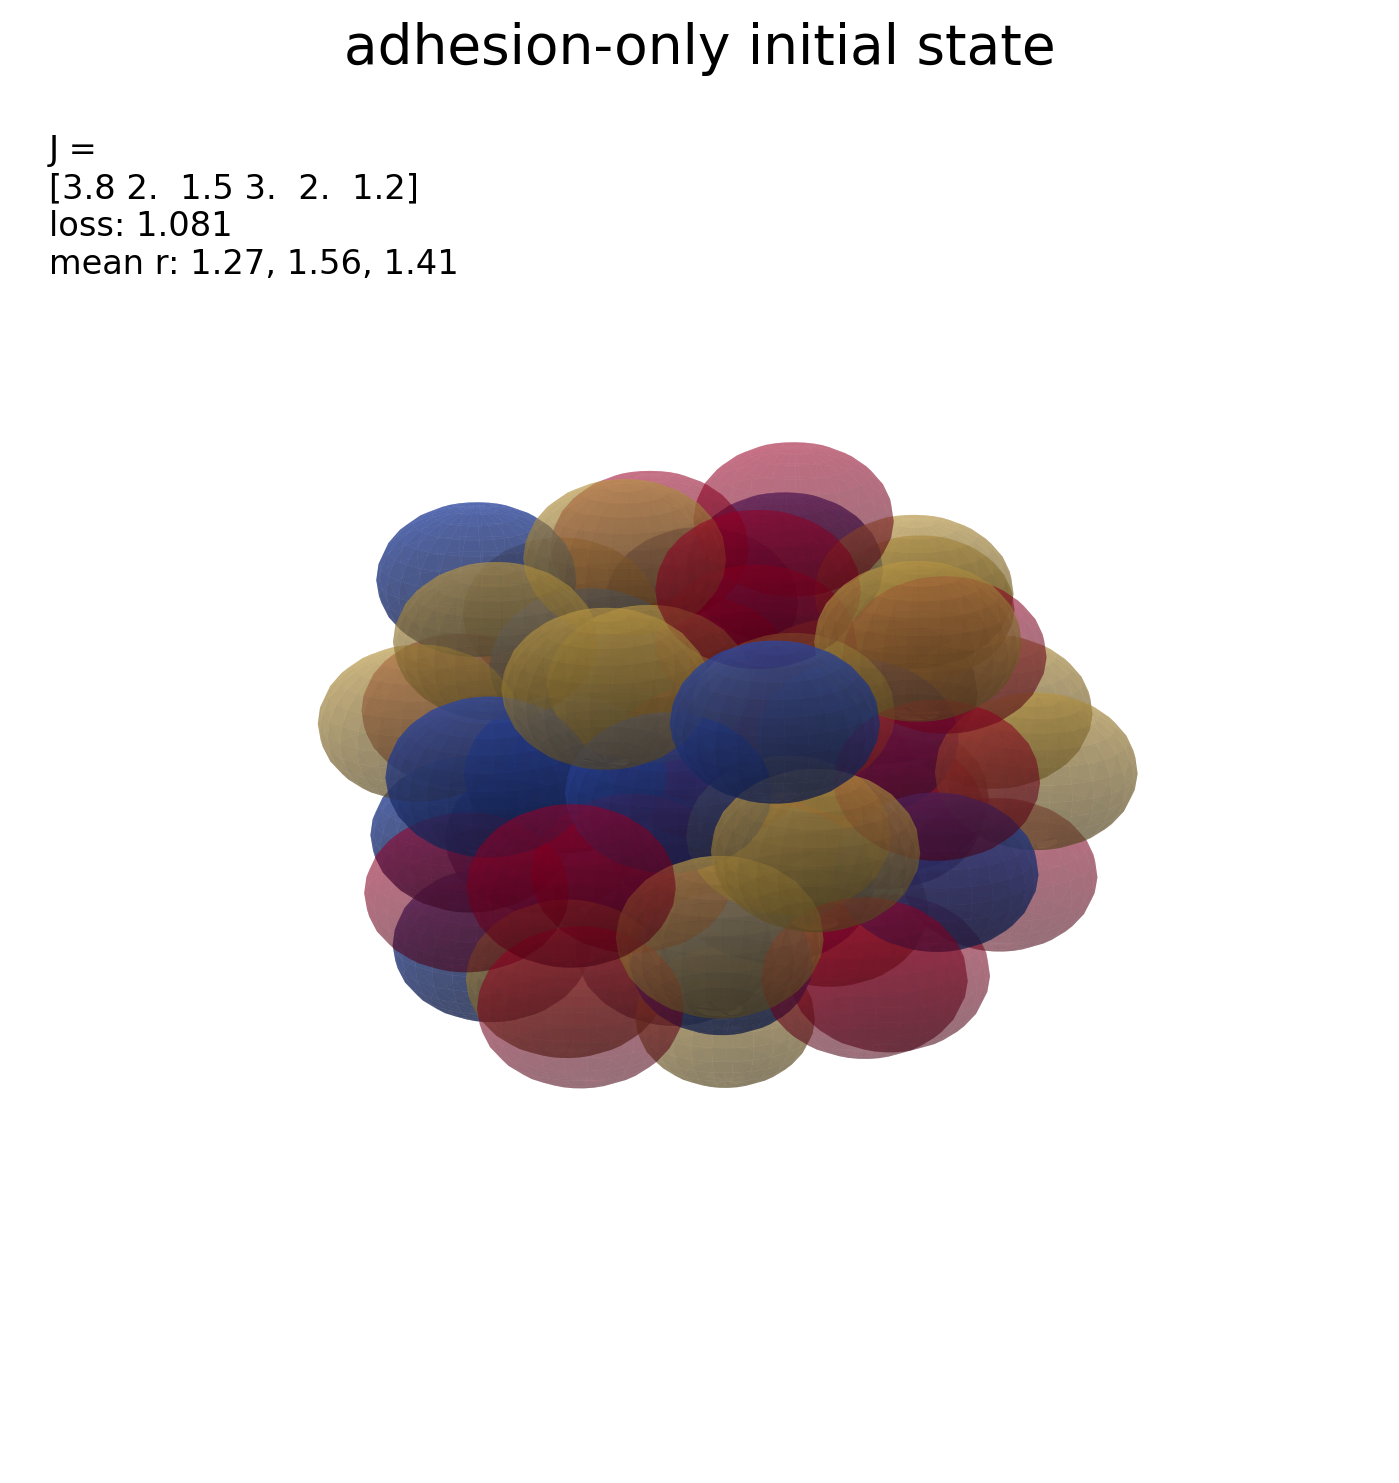

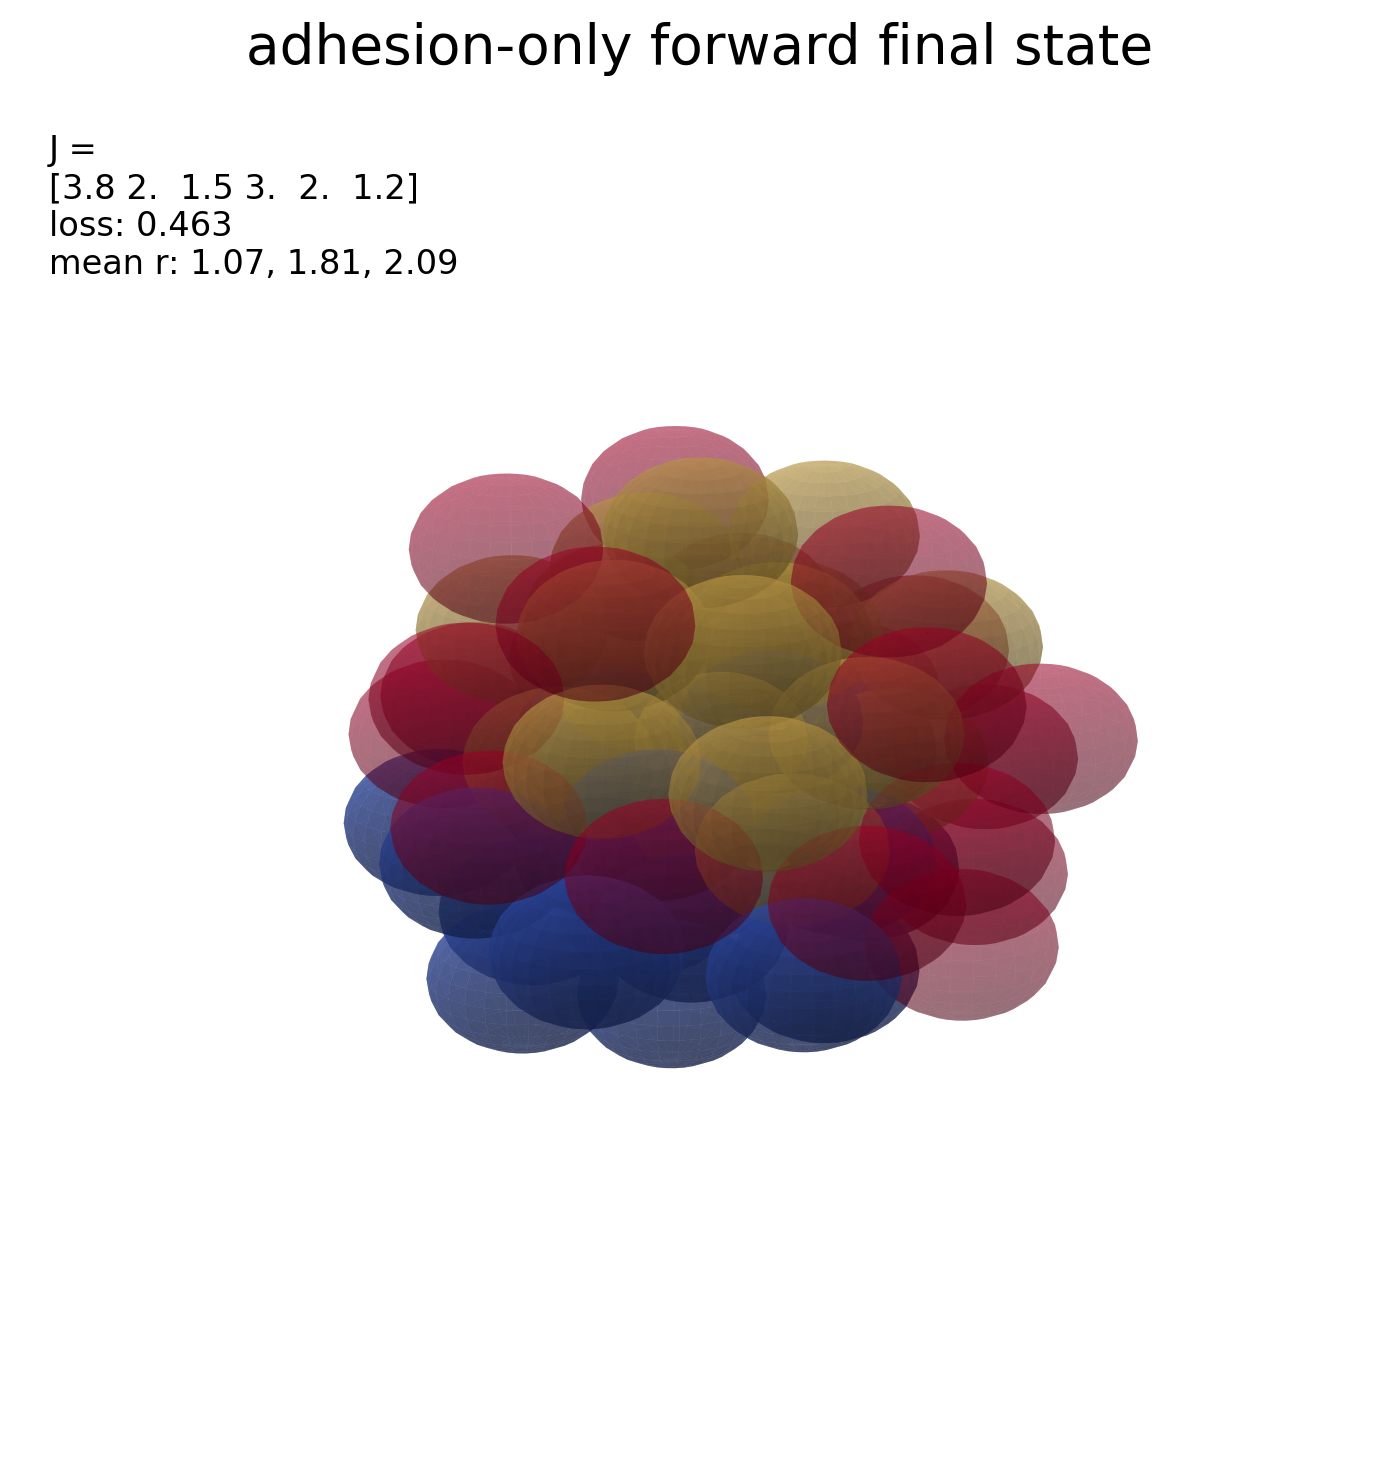

In [328]:
target_radii = np.array([TARGET_R1, TARGET_R2, TARGET_R3])

def hidden_type_from_color(color):
    if color is None:
        return None
    if isinstance(color, int):
        if color not in (1, 2, 3):
            raise ValueError("Use cell type 1, 2, or 3.")
        return color - 1
    color_to_type = {"blue": 0, "yellow": 1, "red": 2}
    try:
        return color_to_type[color.lower()]
    except KeyError as exc:
        raise ValueError("Use None, 'blue', 'yellow', 'red', 1, 2, or 3.") from exc

hidden_final_type = hidden_type_from_color(HIDE_FINAL_COLOR)

preview_outputs = forward_viz.save_initial_final_visualizations(
    notebook_dir=NOTEBOOK_DIR,
    outdir=FORWARD_OUTDIR,
    istate=istate_adhesion,
    fstate=fstate_adhesion,
    target_j=J,
    target_radii=target_radii,
    loss_fn=istate_and_model.core_shell_loss,
    hidden_final_type=hidden_final_type,
)

initial_metrics = preview_outputs["initial_metrics"]
final_metrics = preview_outputs["final_metrics"]

print("Initial metrics:", initial_metrics)
print("Final metrics:", final_metrics)
if HIDE_FINAL_COLOR is not None:
    print(f"Final render hides: {HIDE_FINAL_COLOR}")
display(DisplayImage(filename=preview_outputs["initial_path"], width=420))
display(DisplayImage(filename=preview_outputs["final_path"], width=420))


In [329]:
# animation_outputs = forward_viz.save_forward_animation(
#     outdir=FORWARD_OUTDIR,
#     istate=istate_adhesion,
#     trajectory=trajectory_adhesion,
# )

# summary = forward_viz.save_forward_summary(
#     outdir=FORWARD_OUTDIR,
#     target_j=J,
#     target_radii=target_radii,
#     n_type_1=N_TYPE_1,
#     n_type_2=N_TYPE_2,
#     n_type_3=N_TYPE_3,
#     n_steps=N_STEPS,
#     seed=SEED,
#     initial_metrics=initial_metrics,
#     final_metrics=final_metrics,
#     animation_html=animation_outputs["animation_html"],
#     hidden_final_type=hidden_final_type,
# )

# animation_outputs["animation"]


# Load Results

In [330]:
def _count_eqx_arrays(path):
    """Count NumPy arrays in an Equinox leaf stream without deserializing a PyTree."""
    import numpy as onp

    count = 0
    with open(path, "rb") as fh:
        while True:
            try:
                onp.load(fh, allow_pickle=False)
                count += 1
            except EOFError:
                break
    return count


def load_run_data_fig4(run_id):
    """Load training log, initial state, and trained model for a given run."""

    key = jax.random.PRNGKey(0)

    import json

    with open(f"trained_models/train-{EXPERIMENT}-opt-hyperparams.json", "r") as f:
        opt_hyper = json.load(f)

    root_dir = f"trained_models/train-{EXPERIMENT}-{run_id}"
    results_path = f"{root_dir}/results-{EXPERIMENT}-{run_id}.eqx"

    from collections import namedtuple

    OptResults = namedtuple("OptimizationResults", ["model", "loss", "loss_aux", "grad"])

    # The original JAX-Morph training loop saves loss/loss_aux as Python lists.
    # Equinox needs the template list length to exactly match the saved file.
    # Count serialized leaves so interrupted/short local runs load cleanly.
    n_arrays = _count_eqx_arrays(results_path)
    n_log_entries = n_arrays // 2
    opt_results_like = OptResults(
        None,
        [0.0] * n_log_entries,
        [0.0] * n_log_entries,
        None,
    )

    with open(results_path, "rb") as fh:
        opt_results = eqx.tree_deserialise_leaves(fh, like=opt_results_like)

    TrainingLog = namedtuple("TrainingLog", ["loss", "val_loss"])
    training_log = TrainingLog(opt_results.loss, opt_results.loss_aux)

    istate = istate_and_model.build_istate(
        key,
        n_type_1=opt_hyper.get("N_TYPE_1", 10),
        n_type_2=opt_hyper.get("N_TYPE_2", 30),
        n_type_3=opt_hyper.get("N_TYPE_3", 90),
    )

    # Any valid 6-vector works as the deserialisation template; the saved raw_j
    # values are loaded from disk into this model.
    model_template = istate_and_model.build_model(np.array([2.0, 2.0, 2.0, 2.0, 2.0, 2.0]))

    with open(f"{root_dir}/init-{EXPERIMENT}-{run_id}.eqx", "rb") as fh:
        initial_model = eqx.tree_deserialise_leaves(fh, like=model_template)

    with open(f"{root_dir}/trained-{EXPERIMENT}-{run_id}.eqx", "rb") as fh:
        trained_model = eqx.tree_deserialise_leaves(fh, like=model_template)

    print(f"Loaded {n_log_entries} logged epochs from {results_path}")
    return opt_hyper, training_log, istate, initial_model, trained_model


# Single Run

In [331]:
RUN_ID = 1


In [332]:
opt_hyper, training_log, istate, initial_model, trained_model = load_run_data_fig4(
    RUN_ID
)

FileNotFoundError: [Errno 2] No such file or directory: 'trained_models/train-concentric-1/results-concentric-1.eqx'

## Loss Curves


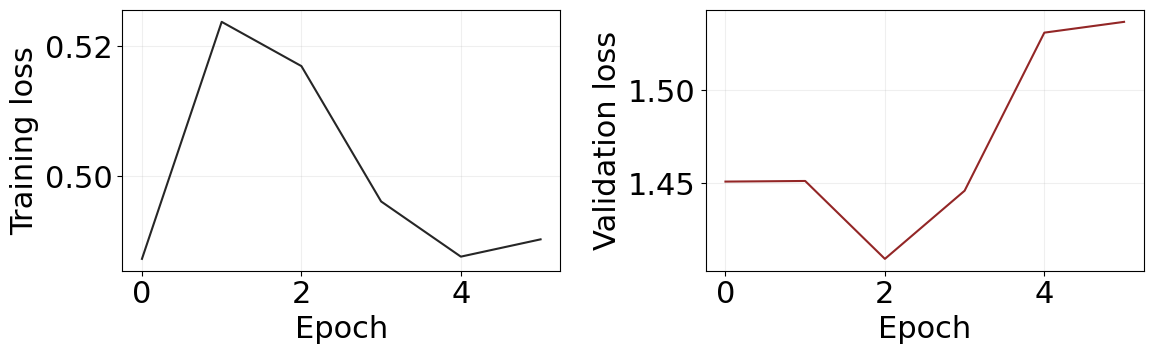

In [ ]:
epochs = np.arange(len(training_log.loss))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(epochs, training_log.loss, color="black", alpha=0.85)
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Training loss")
ax[0].grid(alpha=0.2)

ax[1].plot(epochs, training_log.val_loss, color="maroon", alpha=0.85)
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Validation loss")
ax[1].grid(alpha=0.2)

fig.tight_layout()

if SAVE_FIGURES:
    fig.savefig(f"figures/loss_curves_{EXPERIMENT}-{RUN_ID}.svg", dpi=300)


## Forward Comparison


In [ ]:
TRAINED_OUTDIR = NOTEBOOK_DIR / "trained_forward_outputs"
TRAINED_OUTDIR.mkdir(exist_ok=True)

N_SIM_STEPS = opt_hyper.get("N_STEPS", 50)
TARGET_R1 = opt_hyper.get("TARGET_R1", 1.0)
TARGET_R2 = opt_hyper.get("TARGET_R2", 2.0)
TARGET_R3 = opt_hyper.get("TARGET_R3", 3.0)
target_radii = np.array([TARGET_R1, TARGET_R2, TARGET_R3])

initial_j = istate_and_model.model_visible_j(initial_model)
trained_j = istate_and_model.model_visible_j(trained_model)

sim_key = jax.random.PRNGKey(random.randint(0, 10000))
fstate_initial_model = istate_and_model.simulate_forward(
    initial_model, istate, sim_key, n_steps=N_SIM_STEPS, history=False
)
fstate_trained_model = istate_and_model.simulate_forward(
    trained_model, istate, sim_key, n_steps=N_SIM_STEPS, history=False
)

initial_state_loss = float(istate_and_model.core_shell_loss(istate, TARGET_R1, TARGET_R2, TARGET_R3))
initial_model_loss = float(istate_and_model.core_shell_loss(fstate_initial_model, TARGET_R1, TARGET_R2, TARGET_R3))
trained_model_loss = float(istate_and_model.core_shell_loss(fstate_trained_model, TARGET_R1, TARGET_R2, TARGET_R3))

print("J order: [J_11, J_12, J_13, J_22, J_23, J_33]")
print("Initial J:", np.asarray(initial_j))
print("Trained J:", np.asarray(trained_j))
print(f"Initial state loss: {initial_state_loss:.3f}")
print(f"Final loss with initial J: {initial_model_loss:.3f}")
print(f"Final loss with trained J: {trained_model_loss:.3f}")


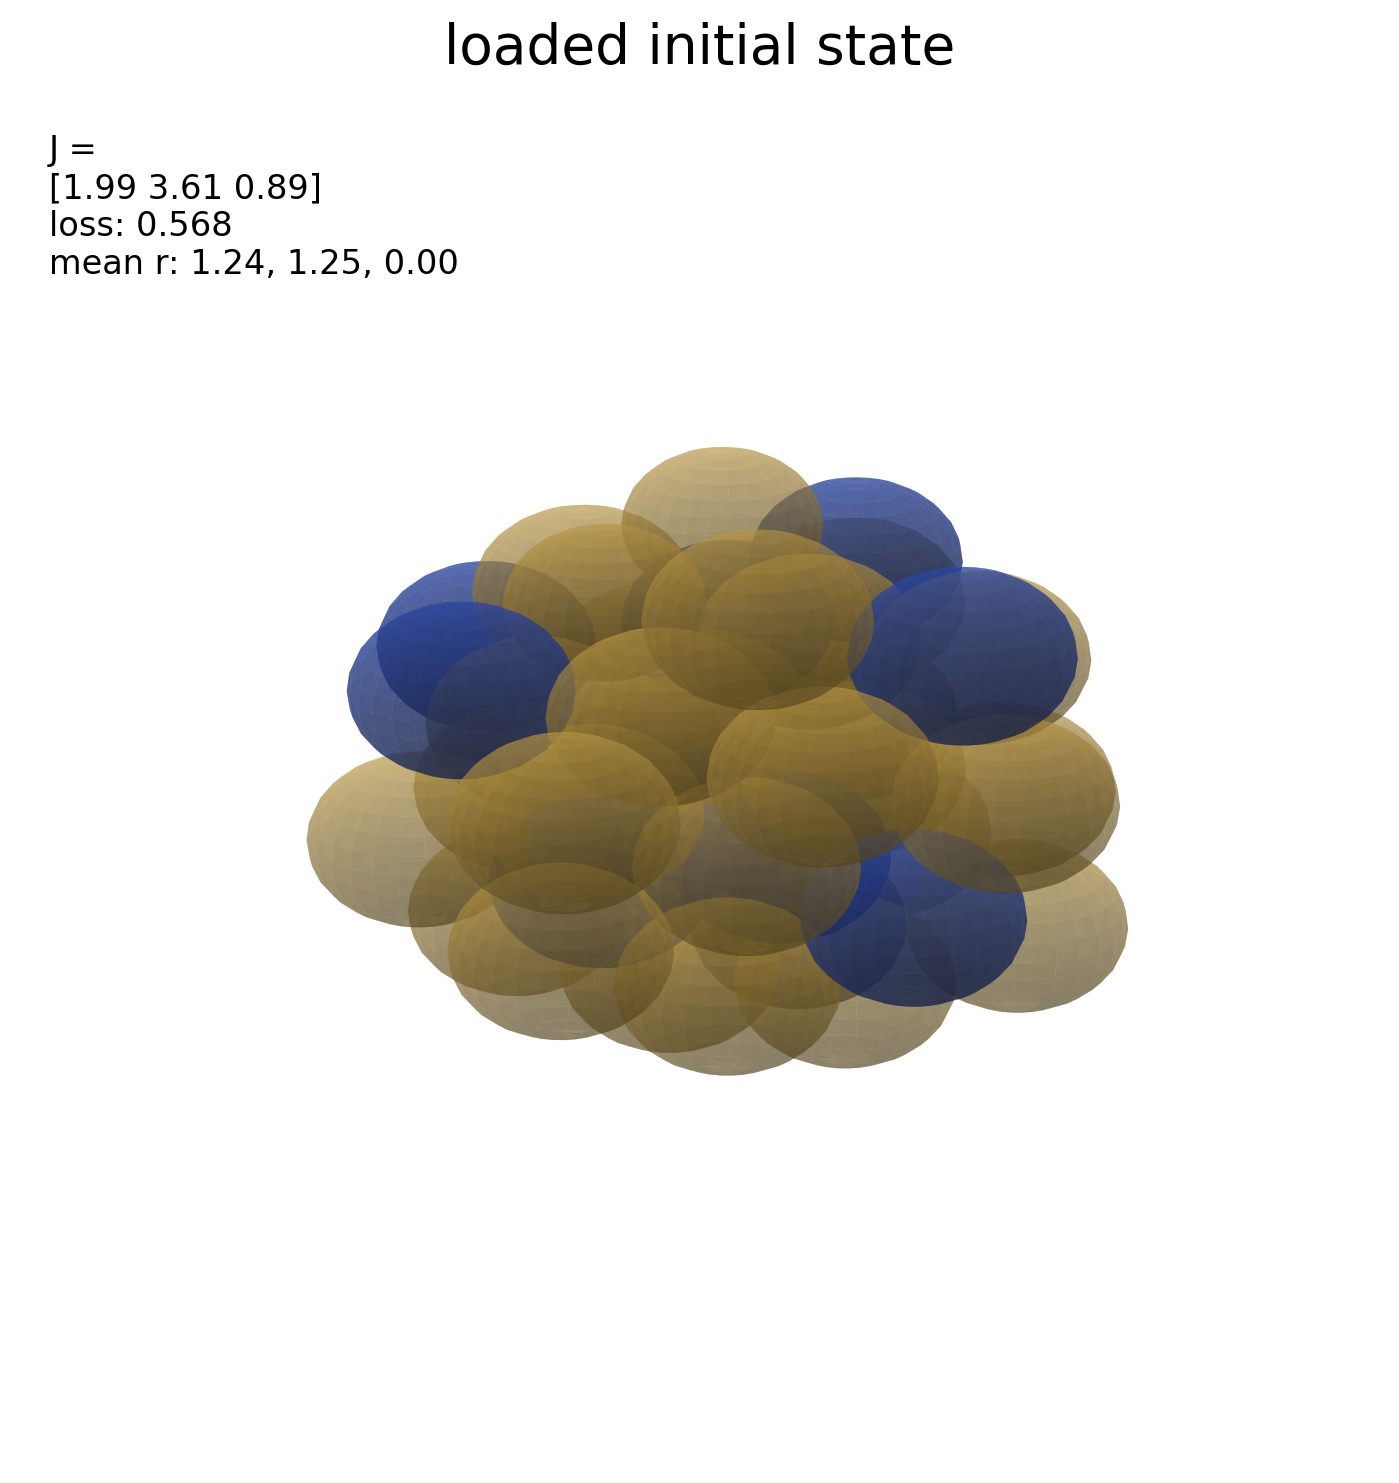

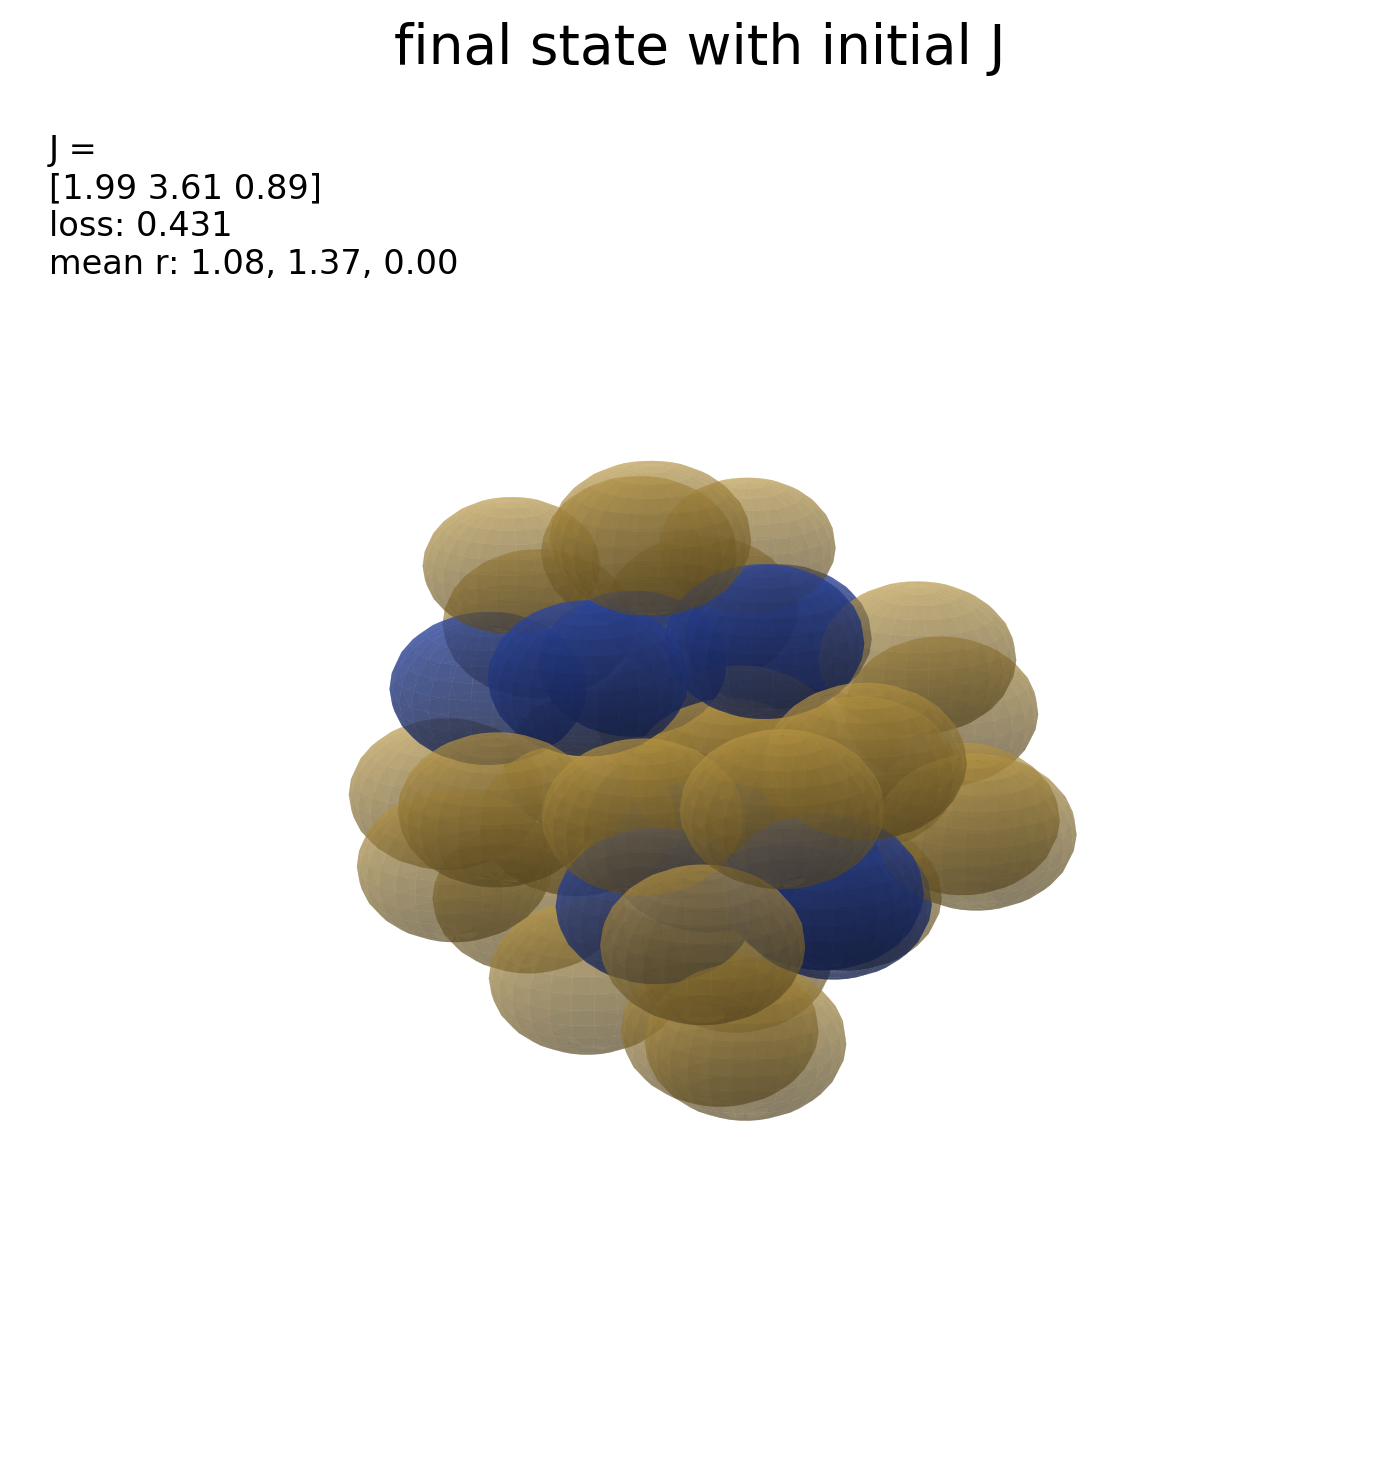

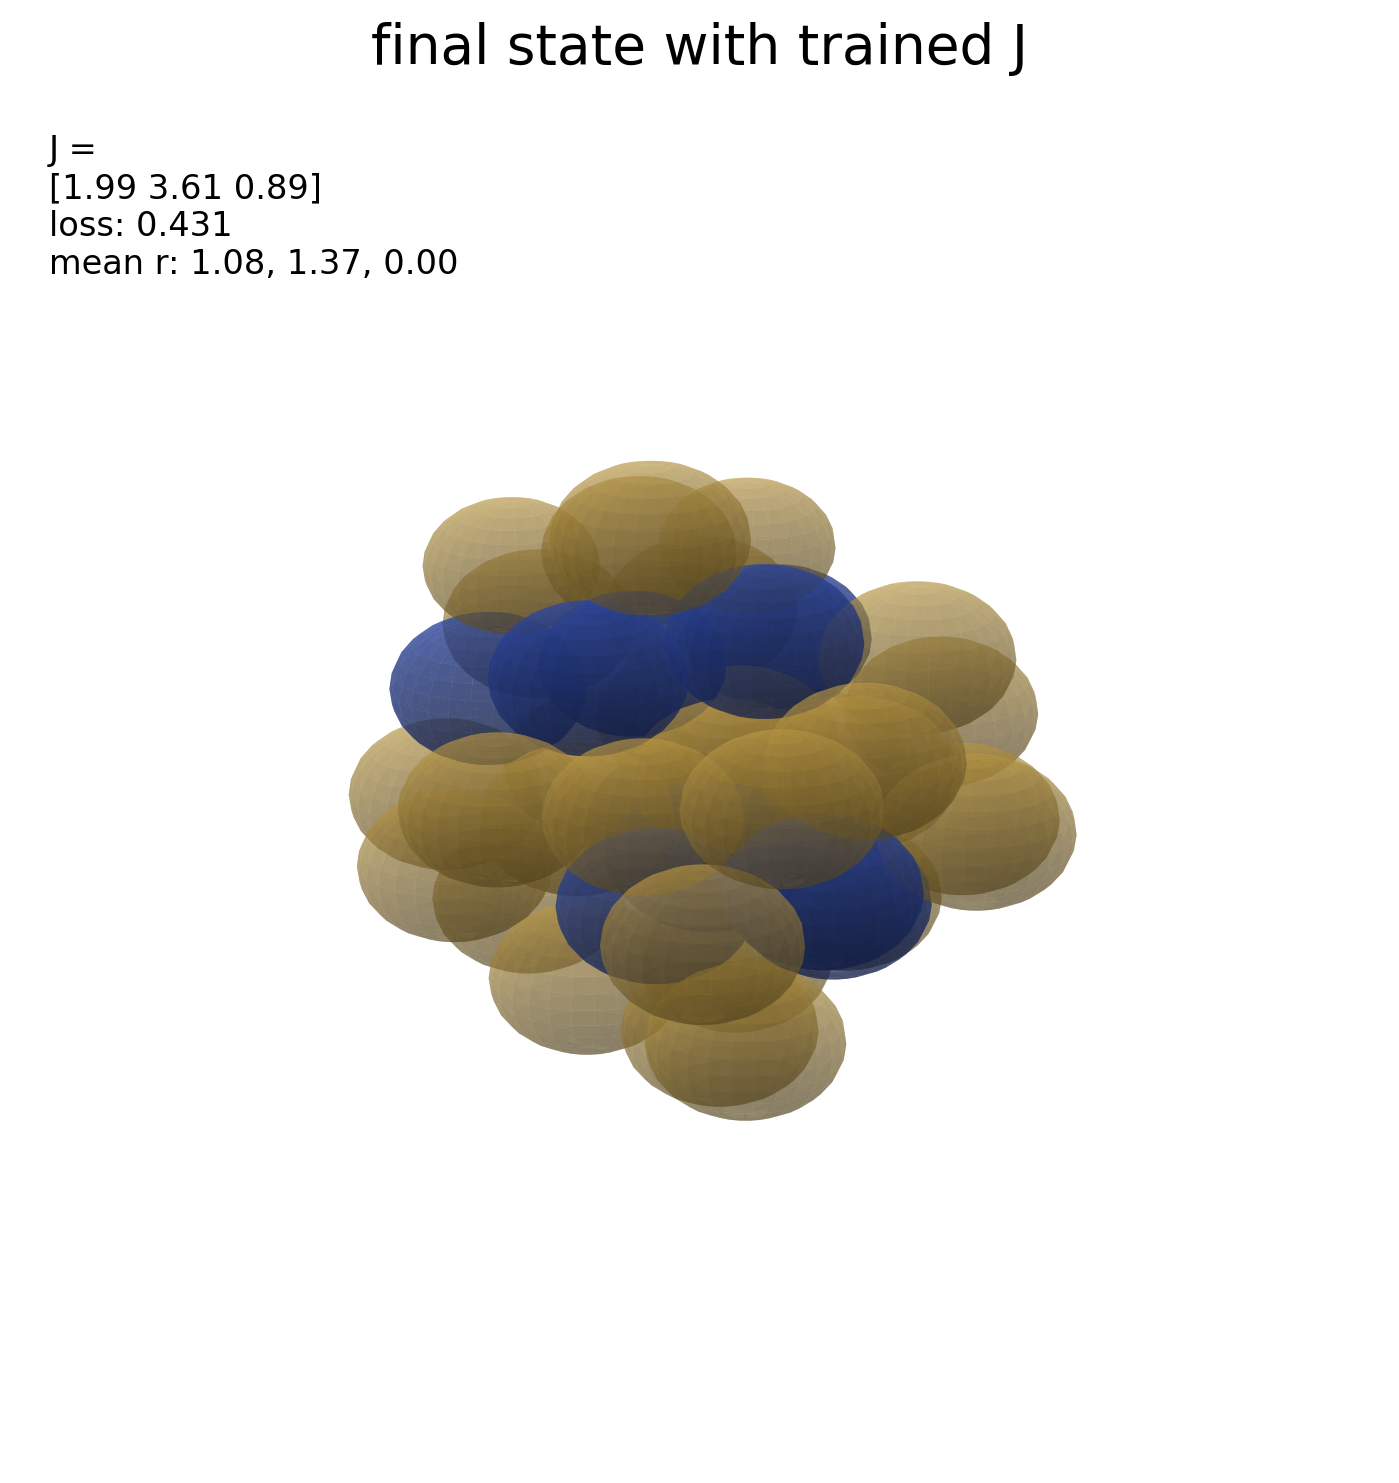

In [ ]:
initial_preview = forward_viz.save_state_visualization(
    notebook_dir=NOTEBOOK_DIR,
    outdir=TRAINED_OUTDIR,
    state=istate,
    title="loaded initial state",
    filename=f"{EXPERIMENT}-{RUN_ID}-initial-state.png",
    target_j=trained_j,
    target_radii=target_radii,
    loss_fn=istate_and_model.core_shell_loss,
)

untrained_preview = forward_viz.save_state_visualization(
    notebook_dir=NOTEBOOK_DIR,
    outdir=TRAINED_OUTDIR,
    state=fstate_initial_model,
    title="final state with initial J",
    filename=f"{EXPERIMENT}-{RUN_ID}-final-initial-j.png",
    target_j=initial_j,
    target_radii=target_radii,
    loss_fn=istate_and_model.core_shell_loss,
)

trained_preview = forward_viz.save_state_visualization(
    notebook_dir=NOTEBOOK_DIR,
    outdir=TRAINED_OUTDIR,
    state=fstate_trained_model,
    title="final state with trained J",
    filename=f"{EXPERIMENT}-{RUN_ID}-final-trained-j.png",
    target_j=trained_j,
    target_radii=target_radii,
    loss_fn=istate_and_model.core_shell_loss,
)

display(DisplayImage(filename=initial_preview["path"], width=360))
display(DisplayImage(filename=untrained_preview["path"], width=360))
display(DisplayImage(filename=trained_preview["path"], width=360))
